# Visual Analysis of Results

In this lab note book, I will document the analysis of the results of the experiments from my masters thesis.

## Step 1: Loading of experiment objects

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_exp1 = pd.read_csv("metrics_exp1/episode_metrics_exp1.csv")
df_exp2 = pd.read_csv("metrics_exp2/episode_metrics_exp2.csv")
df_exp3 = pd.read_csv("metrics_exp3/episode_metrics_exp3.csv")
df_exp4 = pd.read_csv("metrics_exp4/episode_metrics_exp4.csv")

print(len(df_exp1))
print(len(df_exp2))
print(len(df_exp3))
print(len(df_exp4))


5778
5842
5462
5931


In [41]:
# make them all the same length

dfs = [df_exp1, df_exp2, df_exp3, df_exp4]

min_len = min(len(df) for df in dfs)

# 5000 episodes
min_len = 5000

dfs = [df.iloc[:min_len] for df in dfs]

df_exp1, df_exp2, df_exp3, df_exp4 = dfs

print(len(df_exp1))
print(len(df_exp2))
print(len(df_exp3))
print(len(df_exp4))

5000
5000
5000
5000


## Step 2: Inspecting columns and generating summaries

In [42]:
print(df_exp1.columns)
df_exp1.describe()

Index(['experiment', 'iteration', 'episode_id', 'elapsed_steps',
       'total_reward', 'living_reward_sum', 'goal_reward_sum',
       'progress_reward_sum', 'conflict_penalty_sum', 'completion_rate',
       'agents_completed', 'mean_arrival_step', 'throughput', 'blocked_steps',
       'num_block_events', 'mean_block_duration', 'max_block_duration',
       'mean_waiting_steps_per_agent'],
      dtype='str')


,iteration,episode_id,elapsed_steps,total_reward,living_reward_sum,goal_reward_sum,progress_reward_sum,conflict_penalty_sum,completion_rate,agents_completed,mean_arrival_step,throughput,blocked_steps,num_block_events,mean_block_duration,max_block_duration,mean_waiting_steps_per_agent
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0,5000.0,5000.000000,5000.000000,3975.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,142.584200,118.981200,235.767600,-319.988304,-9.430704,-310.557600,0.0,0.0,0.385750,1.543000,163.719602,0.007195,303.145400,39.403000,10.106340,88.11900,76.456283
std,104.082972,94.601742,66.966571,189.288112,2.678663,188.255324,0.0,0.0,0.290691,1.162765,50.058970,0.006635,179.485779,20.758082,9.871091,67.57457,45.041594
min,0.000000,2.000000,46.000000,-1172.760000,-13.280000,-1160.000000,0.0,0.0,0.000000,0.000000,31.000000,0.000000,5.000000,4.000000,1.090909,2.00000,1.666667
25%,45.000000,41.000000,196.000000,-432.650000,-12.760000,-423.000000,0.0,0.0,0.250000,1.000000,134.000000,0.003067,147.000000,25.000000,2.974012,21.00000,37.000000
50%,139.000000,93.000000,233.000000,-296.180000,-9.320000,-288.000000,0.0,0.0,0.250000,1.000000,159.666667,0.006024,289.500000,35.000000,7.973329,93.00000,73.250000
75%,230.000000,184.000000,319.000000,-190.540000,-7.840000,-181.000000,0.0,0.0,0.500000,2.000000,192.000000,0.009950,429.250000,50.000000,13.524436,127.00000,108.250000
max,341.000000,394.000000,332.000000,-4.280000,-1.840000,0.000000,0.0,0.0,1.000000,4.000000,328.000000,0.086957,1110.000000,169.000000,201.800000,297.00000,277.500000


In [43]:
# experiment 2
df_exp2.describe()

,iteration,episode_id,elapsed_steps,total_reward,living_reward_sum,goal_reward_sum,progress_reward_sum,conflict_penalty_sum,completion_rate,agents_completed,mean_arrival_step,throughput,blocked_steps,num_block_events,mean_block_duration,max_block_duration,mean_waiting_steps_per_agent
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.0000,5000.0000,3890.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,150.459200,142.698800,237.141200,-311.502178,-9.485648,-296.788000,11.13602,-16.364550,0.3674,1.4696,174.946015,0.006633,327.291000,59.944800,6.428085,67.147000,81.838817
std,109.728959,120.796296,65.429965,200.386090,2.617199,189.684893,7.85133,8.127679,0.2766,1.1064,49.742421,0.005677,162.553578,21.102664,4.933840,64.824608,40.624478
min,0.000000,2.000000,46.000000,-1182.570000,-13.280000,-1134.000000,-26.75000,-51.000000,0.0000,0.0000,39.000000,0.000000,32.000000,10.000000,1.458824,4.000000,8.000000
25%,45.000000,45.000000,197.000000,-434.915000,-12.800000,-411.000000,7.00000,-22.000000,0.2500,1.0000,144.000000,0.003049,196.000000,45.000000,2.902711,17.000000,49.000000
50%,143.000000,108.000000,234.000000,-284.985000,-9.360000,-273.000000,11.85000,-14.900000,0.2500,1.0000,171.416667,0.005714,298.000000,59.000000,4.629022,37.000000,74.500000
75%,244.000000,217.000000,320.000000,-155.170000,-7.880000,-148.000000,17.00000,-9.800000,0.5000,2.0000,203.000000,0.009804,440.000000,74.000000,8.435462,103.000000,110.000000
max,346.000000,524.000000,332.000000,11.160000,-1.840000,0.000000,24.10000,-1.600000,1.0000,4.0000,326.000000,0.065574,1020.000000,171.000000,46.818182,288.000000,255.000000


In [44]:
# experiment 3

df_exp3.describe()

,iteration,episode_id,elapsed_steps,total_reward,living_reward_sum,goal_reward_sum,progress_reward_sum,conflict_penalty_sum,completion_rate,agents_completed,...,mean_waiting_steps_per_agent,traffic_light_red_steps,traffic_light_green_events,traffic_light_release_events,traffic_light_auto_reserve_events,mean_traffic_light_wait_per_agent,num_traffic_light_entries,most_blocked_entry_red_steps,num_traffic_light_directions_used,dominant_traffic_light_direction_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.00000,5000.0000,5000.00000,5000.000000,5000.000000
mean,148.143400,100.714200,236.013200,-284.721038,-9.440528,-273.34860,11.398590,-13.330500,0.472950,1.891800,...,66.837917,0.541800,2.903800,7.216200,4.3974,0.46780,0.2122,0.53020,1.780400,6.079000
std,114.067557,85.548535,66.518006,205.043936,2.660720,194.32241,7.968593,7.700004,0.295886,1.183543,...,38.442419,5.696871,7.854507,7.987629,1.9187,4.20113,0.4359,5.67619,0.418343,7.929069
min,0.000000,2.000000,48.000000,-1132.590000,-13.280000,-1071.00000,-32.750000,-50.000000,0.000000,0.000000,...,6.750000,0.000000,0.000000,0.000000,0.0000,0.00000,0.0000,0.00000,0.000000,0.000000
25%,46.000000,30.000000,196.000000,-414.770000,-12.800000,-396.00000,6.600000,-17.950000,0.250000,1.000000,...,36.000000,0.000000,1.000000,5.000000,3.0000,0.00000,0.0000,0.00000,2.000000,4.000000
50%,143.000000,77.000000,233.000000,-260.320000,-9.320000,-249.00000,12.150000,-11.700000,0.500000,2.000000,...,58.750000,0.000000,2.000000,6.000000,4.0000,0.00000,0.0000,0.00000,2.000000,5.000000
75%,240.000000,152.000000,320.000000,-117.667500,-7.840000,-114.00000,17.750000,-7.150000,0.750000,3.000000,...,89.750000,0.000000,3.000000,8.000000,6.0000,0.00000,0.0000,0.00000,2.000000,7.000000
max,369.000000,371.000000,332.000000,12.350000,-1.920000,0.00000,24.200000,-1.150000,1.000000,4.000000,...,250.000000,280.000000,157.000000,161.000000,18.0000,140.00000,2.0000,279.00000,2.000000,162.000000


In [45]:
# experiment 4

df_exp4.describe()

,iteration,episode_id,elapsed_steps,total_reward,living_reward_sum,goal_reward_sum,progress_reward_sum,conflict_penalty_sum,completion_rate,agents_completed,...,mean_waiting_steps_per_agent,traffic_light_red_steps,traffic_light_green_events,traffic_light_release_events,traffic_light_auto_reserve_events,mean_traffic_light_wait_per_agent,num_traffic_light_entries,most_blocked_entry_red_steps,num_traffic_light_directions_used,dominant_traffic_light_direction_count
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0,5000.0,5000.000000,5000.000000,...,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,144.384000,135.32320,237.687600,-334.192904,-9.507504,-324.685400,0.0,0.0,0.354750,1.419000,...,85.076917,0.37480,3.641200,7.470400,3.887600,0.303267,0.167400,0.364600,1.705600,6.417000
std,108.150041,134.71227,67.136085,193.976408,2.685443,192.955692,0.0,0.0,0.286236,1.144946,...,44.658336,3.72976,12.362517,12.316049,1.967267,2.777102,0.399261,3.702865,0.461921,12.298169
min,0.000000,2.00000,49.000000,-1089.760000,-13.280000,-1077.000000,0.0,0.0,0.000000,0.000000,...,5.666667,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,38.00000,196.000000,-450.510000,-12.840000,-441.000000,0.0,0.0,0.250000,1.000000,...,48.250000,0.00000,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,1.000000,3.000000
50%,140.000000,87.50000,233.000000,-306.700000,-9.320000,-297.000000,0.0,0.0,0.250000,1.000000,...,79.250000,0.00000,2.000000,6.000000,4.000000,0.000000,0.000000,0.000000,2.000000,5.000000
75%,238.000000,190.00000,321.000000,-203.320000,-7.840000,-195.000000,0.0,0.0,0.500000,2.000000,...,115.500000,0.00000,3.000000,8.000000,5.000000,0.000000,0.000000,0.000000,2.000000,7.000000
max,338.000000,653.00000,332.000000,-4.360000,-1.960000,0.000000,0.0,0.0,1.000000,4.000000,...,276.750000,128.00000,218.000000,219.000000,14.000000,128.000000,2.000000,128.000000,2.000000,220.000000


In [46]:
# comparable summary table

metrics = [
    'total_reward',
    'completion_rate',
    'mean_arrival_step',
    'throughput',
    'blocked_steps',
    'num_block_events',
    'mean_block_duration',
    'max_block_duration',
    'mean_waiting_steps_per_agent'
]

# cut to the last 500 episodes
df_exp1_last_500 = df_exp1.tail(500)
df_exp2_last_500 = df_exp2.tail(500)
df_exp3_last_500 = df_exp3.tail(500)
df_exp4_last_500 = df_exp4.tail(500)

dfs = {
    'exp1': df_exp1_last_500,
    'exp2': df_exp2_last_500,
    'exp3': df_exp3_last_500,
    'exp4': df_exp4_last_500,
}

summary = pd.DataFrame(index=metrics)

for name, df in dfs.items():
    summary[f'{name}_mean'] = df[metrics].mean()
    summary[f'{name}_std'] = df[metrics].std()

summary = summary.round(5)

summary

,exp1_mean,exp1_std,exp2_mean,exp2_std,exp3_mean,exp3_std,exp4_mean,exp4_std
total_reward,-269.02640,183.79679,-263.53078,193.75051,-256.73878,195.39935,-302.89816,194.41639
completion_rate,0.50600,0.27315,0.52700,0.27645,0.56050,0.27860,0.45000,0.28708
mean_arrival_step,165.99510,45.57082,167.39795,47.06490,161.51896,48.16715,175.59751,51.57129
throughput,0.00955,0.00648,0.00975,0.00591,0.01083,0.00763,0.00817,0.00620
blocked_steps,250.85600,170.52863,241.82200,154.82434,205.93000,150.17819,300.66200,169.66289
num_block_events,49.72800,22.57834,56.14800,21.32819,39.59000,14.14787,47.19600,16.80877
mean_block_duration,6.80115,8.15528,5.74890,6.40720,6.27318,8.36891,7.72867,6.45501
max_block_duration,66.47800,71.52278,58.50000,73.92358,54.56000,58.78433,77.82800,64.22570
mean_waiting_steps_per_agent,63.10367,42.85690,60.48383,38.69810,52.67833,37.90698,75.16550,42.41572


## Step 3: Plots for Reward breakdown

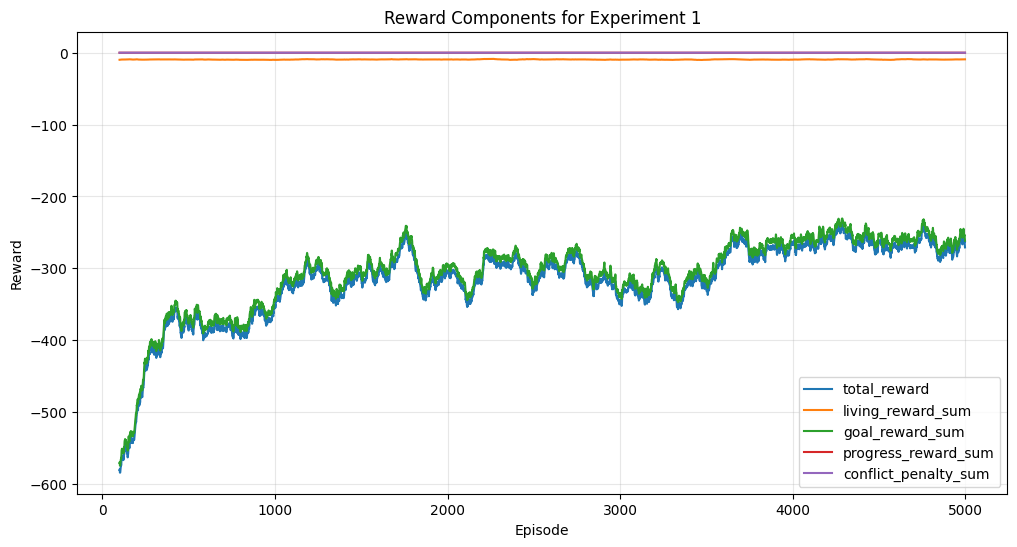

In [47]:
reward_cols = [
    "total_reward",
    "living_reward_sum",
    "goal_reward_sum",
    "progress_reward_sum",
    "conflict_penalty_sum"
]

window = 100

plt.figure(figsize=(12, 6))

for col in reward_cols:
    plt.plot(
        df_exp1[col].rolling(window=window).mean(),
        label=col
    )

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title(f"Reward Components for Experiment 1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

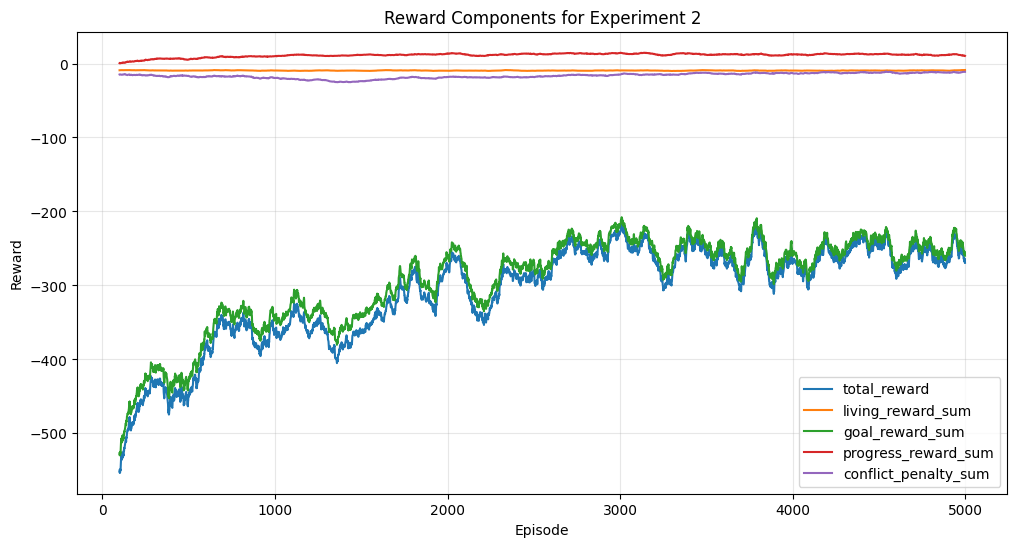

In [48]:
reward_cols = [
    "total_reward",
    "living_reward_sum",
    "goal_reward_sum",
    "progress_reward_sum",
    "conflict_penalty_sum"
]

window = 100

plt.figure(figsize=(12, 6))

for col in reward_cols:
    plt.plot(
        df_exp2[col].rolling(window=window).mean(),
        label=col
    )

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title(f"Reward Components for Experiment 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

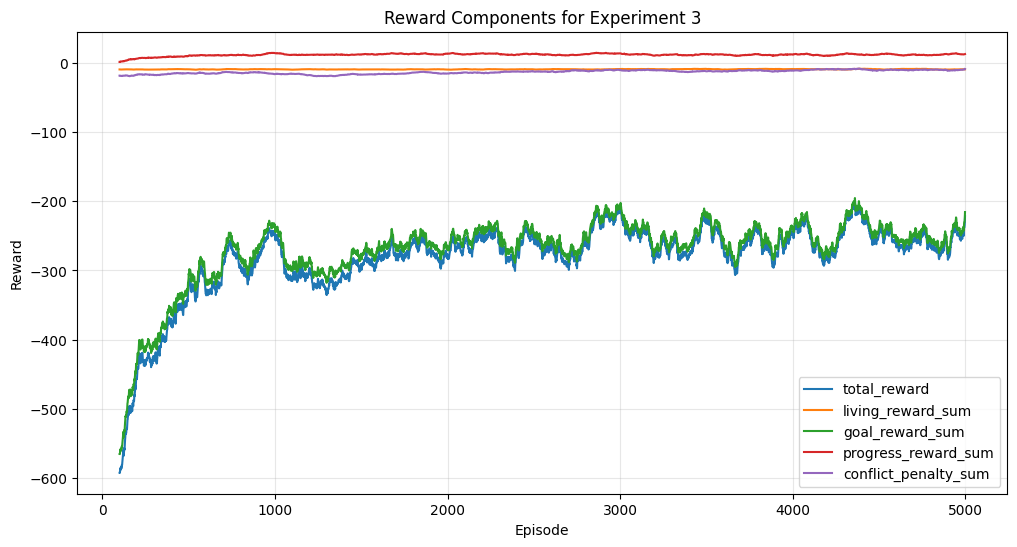

In [49]:
reward_cols = [
    "total_reward",
    "living_reward_sum",
    "goal_reward_sum",
    "progress_reward_sum",
    "conflict_penalty_sum"
]

window = 100

plt.figure(figsize=(12, 6))

for col in reward_cols:
    plt.plot(
        df_exp3[col].rolling(window=window).mean(),
        label=col
    )

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title(f"Reward Components for Experiment 3")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

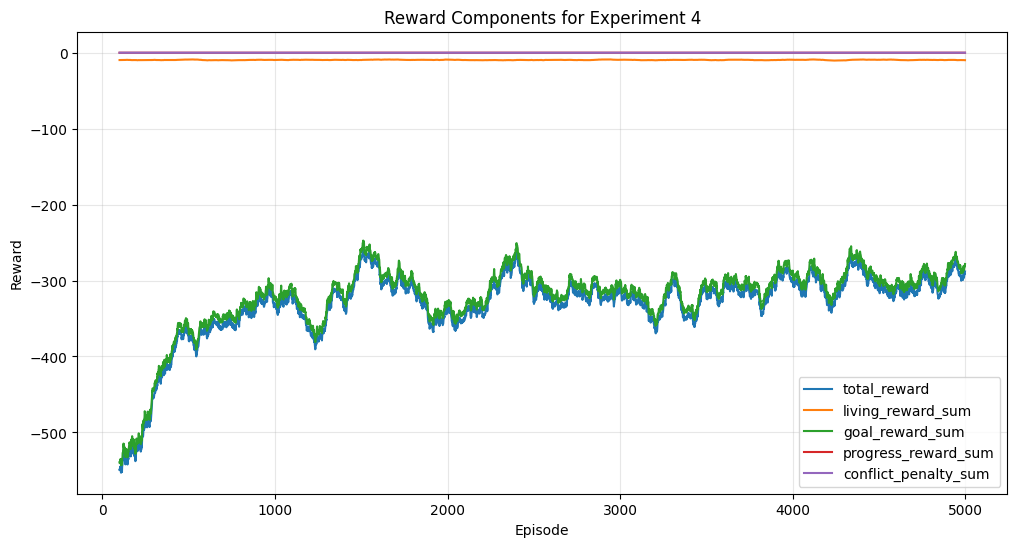

In [50]:
reward_cols = [
    "total_reward",
    "living_reward_sum",
    "goal_reward_sum",
    "progress_reward_sum",
    "conflict_penalty_sum"
]

window = 100

plt.figure(figsize=(12, 6))

for col in reward_cols:
    plt.plot(
        df_exp4[col].rolling(window=window).mean(),
        label=col
    )

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title(f"Reward Components for Experiment 4")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Stp 4: Comparison Plots for Rewards

After careful consideration from Step 3, it is more sensible to analyze the components of the reward in the direct comparison to each other.

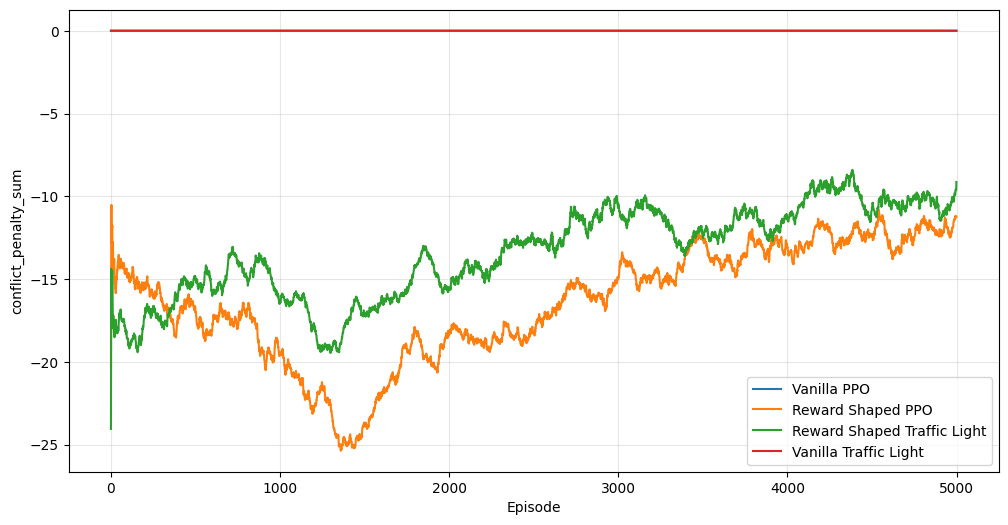

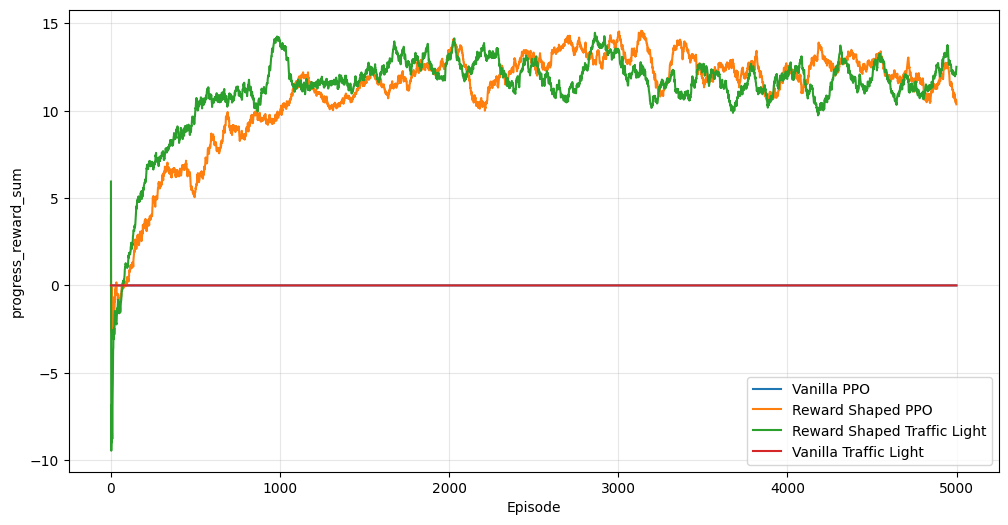

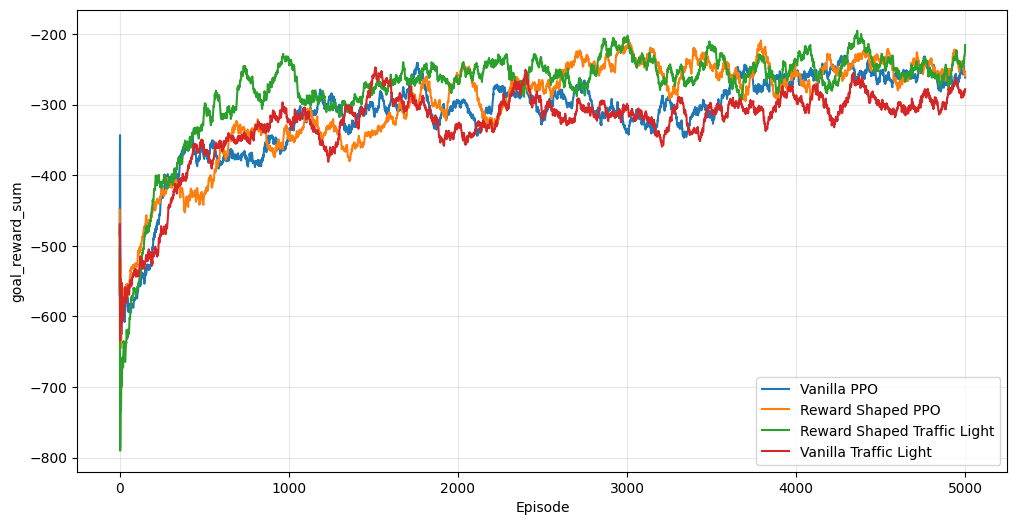

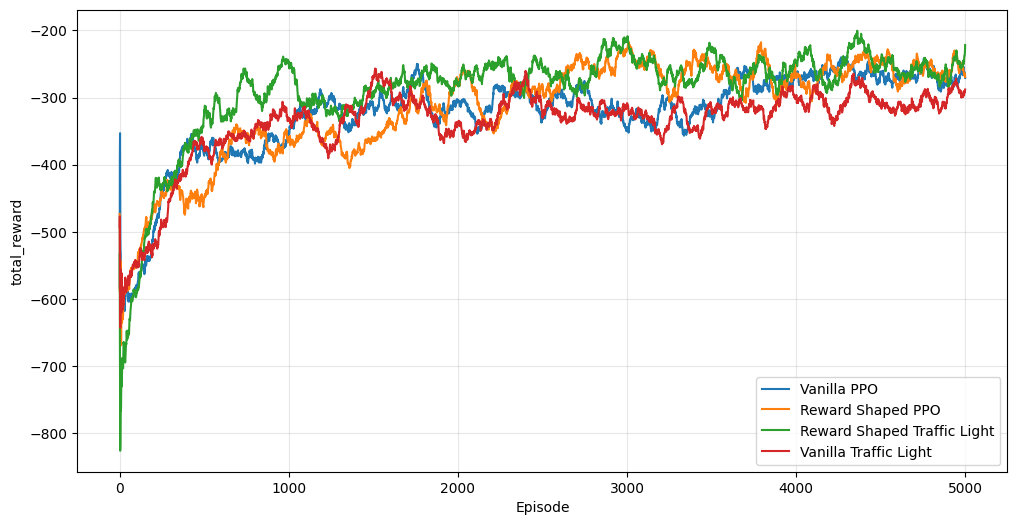

In [51]:
dfs = [df_exp1, df_exp2, df_exp3, df_exp4]
labels = ["Vanilla PPO", "Reward Shaped PPO", "Reward Shaped Traffic Light", "Vanilla Traffic Light"]

components = [
    "conflict_penalty_sum",
    "progress_reward_sum",
    "goal_reward_sum",
    "total_reward"
]

window = 100

for component in components:
    plt.figure(figsize=(12, 6))

    for df, label in zip(dfs, labels):
        smoothed = df[component].rolling(window=window, min_periods=1).mean()
        plt.plot(smoothed, label=label)

    plt.xlabel("Episode")
    plt.ylabel(component)
    #plt.title(f"{component} across experiments ({window}-step rolling average)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Step 5: Analyze completion rate and throughput

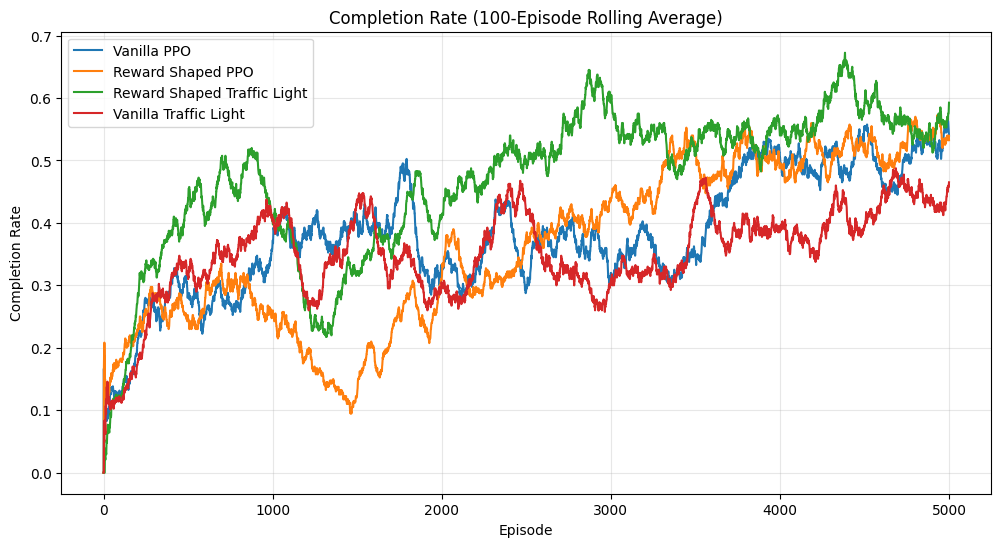

In [52]:
plt.figure(figsize=(12,6))

for df, label in zip(dfs, labels):
    smoothed = (
        df["completion_rate"]
        .rolling(window=100, min_periods=1)
        .mean()
    )
    plt.plot(smoothed, label=label)

plt.xlabel("Episode")
plt.ylabel("Completion Rate")
plt.title("Completion Rate (100-Episode Rolling Average)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

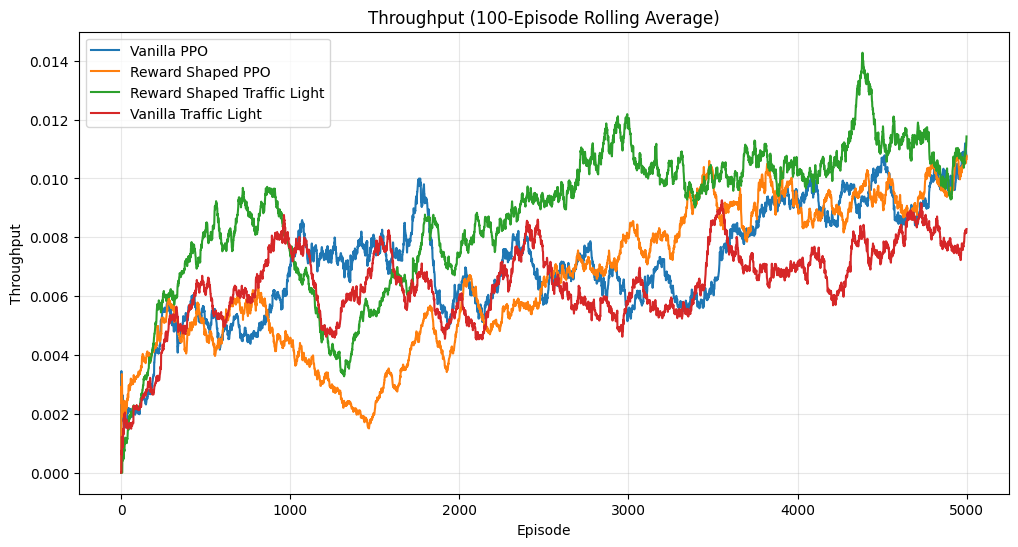

In [53]:
plt.figure(figsize=(12,6))

for df, label in zip(dfs, labels):
    smoothed = (
        df["throughput"]
        .rolling(window=100, min_periods=1)
        .mean()
    )
    plt.plot(smoothed, label=label)

plt.xlabel("Episode")
plt.ylabel("Throughput")
plt.title("Throughput (100-Episode Rolling Average)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 6: Light conflict analysis

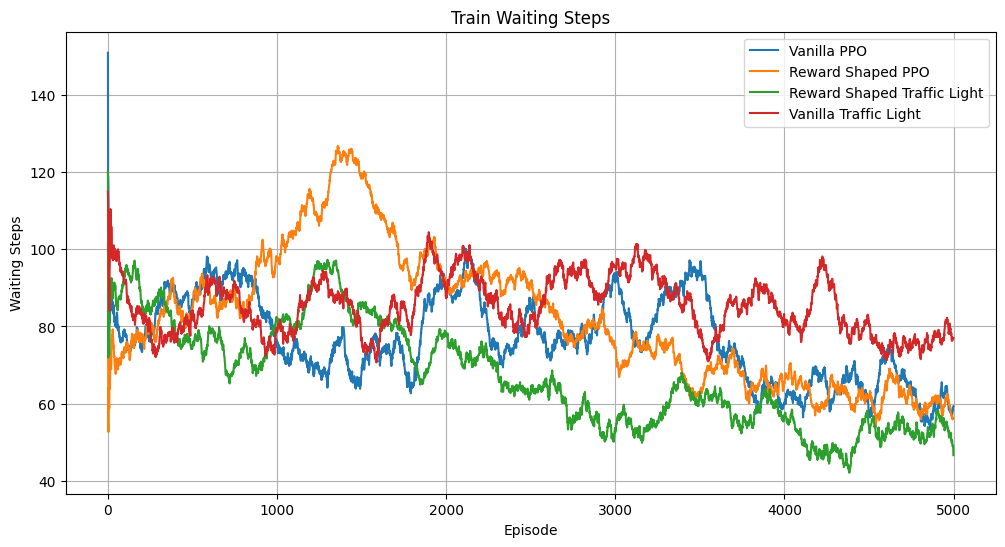

In [54]:
metric = "mean_waiting_steps_per_agent"

plt.figure(figsize=(12, 6))

for df, label in zip(dfs, labels):
    plt.plot(
        df[metric].rolling(100, min_periods=1).mean(),
        label=label
    )

plt.title("Train Waiting Steps")
plt.xlabel("Episode")
plt.ylabel("Waiting Steps")
plt.legend()
plt.grid(True)
plt.show()

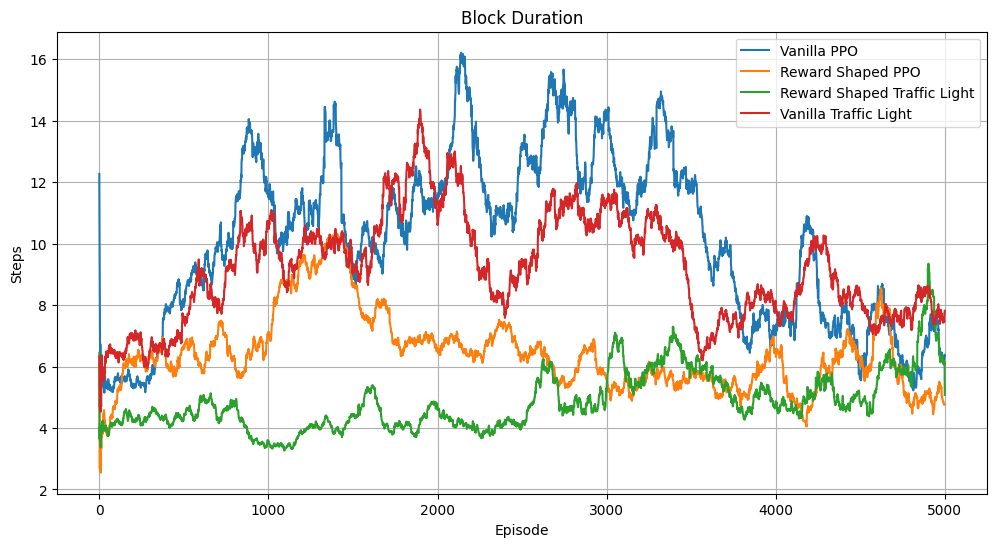

In [55]:
metric = "mean_block_duration"

plt.figure(figsize=(12, 6))

for df, label in zip(dfs, labels):
    plt.plot(
        df[metric].rolling(100, min_periods=1).mean(),
        label=label
    )

plt.title("Block Duration")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.legend()
plt.grid(True)
plt.show()

## Step 7: Statistical Testing for effect sizes

 A two sided comparison test seems like a good idea since I have a lot of data. I will test for the completion rate, mean blockage duration, number of blocked events and mean agent steps.

In [56]:
from scipy.stats import mannwhitneyu

metrics = [
    "completion_rate",
    "num_block_events",
    "mean_block_duration",
    "mean_waiting_steps_per_agent"
]

def rank_biserial(x, y):
    U, p = mannwhitneyu(x, y, alternative="two-sided")

    n1 = len(x)
    n2 = len(y)

    rbc = (2 * U) / (n1 * n2) - 1

    return U, p, rbc

for metric in metrics:

    U, p, rbc = rank_biserial(
    df_exp1_last_500[metric],
    df_exp2_last_500[metric]
)

    print(f"\n{metric}")
    print(f"U = {U:.2f}")
    print(f"p = {p:.8f}")
    print(f"RBC = {rbc:.3f}")


completion_rate
U = 119891.00
p = 0.24674277
RBC = -0.041

num_block_events
U = 101776.50
p = 0.00000037
RBC = -0.186

mean_block_duration
U = 140610.50
p = 0.00063020
RBC = 0.125

mean_waiting_steps_per_agent
U = 125544.00
p = 0.90526236
RBC = 0.004


In [57]:
for metric in metrics:

    U, p, rbc = rank_biserial(
    df_exp2_last_500[metric],
    df_exp3_last_500[metric]
)

    print(f"\n{metric}")
    print(f"U = {U:.2f}")
    print(f"p = {p:.8f}")
    print(f"RBC = {rbc:.3f}")


completion_rate
U = 116204.50
p = 0.04626494
RBC = -0.070

num_block_events
U = 182440.00
p = 0.00000000
RBC = 0.460

mean_block_duration
U = 103144.50
p = 0.00000170
RBC = -0.175

mean_waiting_steps_per_agent
U = 147870.00
p = 0.00000055
RBC = 0.183


In [58]:
for metric in metrics:

    U, p, rbc = rank_biserial(
    df_exp1_last_500[metric],
    df_exp4_last_500[metric]
)

    print(f"\n{metric}")
    print(f"U = {U:.2f}")
    print(f"p = {p:.8f}")
    print(f"RBC = {rbc:.3f}")


completion_rate
U = 138708.00
p = 0.00193623
RBC = 0.110

num_block_events
U = 128960.00
p = 0.38584819
RBC = 0.032

mean_block_duration
U = 88520.00
p = 0.00000000
RBC = -0.292

mean_waiting_steps_per_agent
U = 97493.00
p = 0.00000000
RBC = -0.220


In [59]:
for metric in metrics:

    U, p, rbc = rank_biserial(
    df_exp2_last_500[metric],
    df_exp4_last_500[metric]
)

    print(f"\n{metric}")
    print(f"U = {U:.2f}")
    print(f"p = {p:.8f}")
    print(f"RBC = {rbc:.3f}")


completion_rate
U = 143520.00
p = 0.00002843
RBC = 0.148

num_block_events
U = 155790.00
p = 0.00000000
RBC = 0.246

mean_block_duration
U = 73114.50
p = 0.00000000
RBC = -0.415

mean_waiting_steps_per_agent
U = 93087.50
p = 0.00000000
RBC = -0.255


## Step 9: Preprocessing for Conflict analysis

Making heatmaps for each experiment and blockage frequency and blockage duration plots.

In [60]:
# reading the files
loc_exp1 = pd.read_csv("metrics_exp1/location_metrics_exp1.csv")
loc_exp2 = pd.read_csv("metrics_exp2/location_metrics_exp2.csv")
loc_exp3 = pd.read_csv("metrics_exp3/location_metrics_exp3.csv")
loc_exp4 = pd.read_csv("metrics_exp4/location_metrics_exp4.csv")

print(len(loc_exp1))
print(len(loc_exp2))
print(len(loc_exp3))
print(len(loc_exp4))

n_episodes = (loc_exp1["episode_id"] != loc_exp1["episode_id"].shift()).sum()
print(n_episodes)
n_episodes = (loc_exp2["episode_id"] != loc_exp2["episode_id"].shift()).sum()
print(n_episodes)
n_episodes = (loc_exp3["episode_id"] != loc_exp3["episode_id"].shift()).sum()
print(n_episodes)
n_episodes = (loc_exp4["episode_id"] != loc_exp4["episode_id"].shift()).sum()
print(n_episodes)

220846
320422
313758
240993
5778
5842
5462
5931


From this above we can see that we have different episodes in training again. Since we are only evaluating 5000 episodes, we need to cut off the remaining ones.

In [61]:
def cut_episodes(df, max_episodes=5000, episode_col="episode_id"):
    df = df.copy()

    # define new episode start
    df["episode_seq"] = (df[episode_col] != df[episode_col].shift()).cumsum()

    # cut off at the correct point
    df = df[df["episode_seq"] <= max_episodes].copy()

    return df

In [62]:
# now we use that on all our data frames
loc_exp1 = cut_episodes(loc_exp1, max_episodes=5000, episode_col="episode_id")
loc_exp2 = cut_episodes(loc_exp2, max_episodes=5000, episode_col="episode_id")
loc_exp3 = cut_episodes(loc_exp3, max_episodes=5000, episode_col="episode_id")
loc_exp4 = cut_episodes(loc_exp4, max_episodes=5000, episode_col="episode_id")

# sanity check
n_episodes = (loc_exp1["episode_id"] != loc_exp1["episode_id"].shift()).sum()
print(n_episodes)
n_episodes = (loc_exp2["episode_id"] != loc_exp2["episode_id"].shift()).sum()
print(n_episodes)
n_episodes = (loc_exp3["episode_id"] != loc_exp3["episode_id"].shift()).sum()
print(n_episodes)
n_episodes = (loc_exp4["episode_id"] != loc_exp4["episode_id"].shift()).sum()
print(n_episodes)

5000
5000
5000
5000


## Step 10: Heatmap plotting

In this following section, we are producing analysis plots with heatmaps for the conflict behavior. We are considering: Block frequency heatmap, Block duration heatmap, severity heatmap, top blockage hotspots, blockage duration distribuiton, metrics scatterplot.

In [63]:
# helper functions for all heatmaps/plots

def make_heatmap_from_counts(counts, value_col, height=100, width=100):
    heatmap = np.zeros((height, width))

    for _, row in counts.iterrows():
        x = int(row["x"])
        y = int(row["y"])

        if 0 <= y < height and 0 <= x < width:
            heatmap[x, y] = row[value_col]

    return heatmap


def show_heatmap(
    heatmap,
    title,
    colorbar_label,
    figsize=(10, 8),
    save_path=None
):
    plt.figure(figsize=figsize)
    plt.imshow(heatmap, origin="upper", cmap="viridis")
    plt.colorbar(label=colorbar_label)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved {save_path}")

    plt.show()

In [64]:
# heatmap plotting functions
# (many of them...)

def plot_blocked_duration_heatmap(
    df,
    height=100,
    width=100,
    save_path=None
):
    counts = (
        df.groupby(["x", "y"])["blocked_step_count"]
          .sum()
          .reset_index(name="total_blocked_steps")
    )

    heatmap = make_heatmap_from_counts(
        counts,
        value_col="total_blocked_steps",
        height=height,
        width=width
    )

    show_heatmap(
        heatmap,
        title="Blocked Duration Heatmap",
        colorbar_label="Total blocked steps",
        save_path=save_path
    )

    return counts, heatmap


def plot_blocking_frequency_heatmap(
    df,
    height=100,
    width=100,
    save_path=None
):
    counts = (
        df.groupby(["x", "y"])
          .size()
          .reset_index(name="blocking_frequency")
    )

    heatmap = make_heatmap_from_counts(
        counts,
        value_col="blocking_frequency",
        height=height,
        width=width
    )

    show_heatmap(
        heatmap,
        title="Blocking Frequency Heatmap",
        colorbar_label="Number of blocking records",
        save_path=save_path
    )

    return counts, heatmap


def plot_top_blocking_hotspots(
    df,
    n=20,
    save_path=None
):
    hotspots = (
        df.groupby(["x", "y"])
          .agg(
              total_blocked_steps=("blocked_step_count", "sum"),
              blocking_frequency=("blocked_step_count", "size"),
              mean_blocked_steps=("blocked_step_count", "mean"),
              max_blocked_steps=("blocked_step_count", "max"),
          )
          .reset_index()
          .sort_values("total_blocked_steps", ascending=False)
          .head(n)
    )

    hotspots["cell"] = hotspots.apply(
        lambda row: f"({int(row['y'])}, {int(row['x'])})",
        axis=1
    )

    plt.figure(figsize=(10, 8))
    plt.barh(hotspots["cell"], hotspots["total_blocked_steps"])
    plt.gca().invert_yaxis()
    plt.xlabel("Total blocked steps")
    plt.ylabel("Cell (y, x)")
    plt.title(f"Top {n} Blocking Hotspots")

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved {save_path}")

    plt.show()

    return hotspots


def plot_severity_heatmap(
    df,
    height=100,
    width=100,
    save_path=None
):
    counts = (
        df.groupby(["x", "y"])["blocked_step_count"]
          .mean()
          .reset_index(name="mean_blocked_steps")
    )

    heatmap = make_heatmap_from_counts(
        counts,
        value_col="mean_blocked_steps",
        height=height,
        width=width
    )

    show_heatmap(
        heatmap,
        title="Blocking Severity Heatmap",
        colorbar_label="Mean blocked steps",
        save_path=save_path
    )

    return counts, heatmap


def plot_blockage_duration_distribution(
    df,
    bins=50,
    log_y=True,
    save_path=None
):
    plt.figure(figsize=(10, 6))
    plt.hist(df["blocked_step_count"], bins=bins, log=log_y)
    plt.xlabel("Blocked step count")
    plt.ylabel("Number of records")
    plt.title("Distribution of Blockage Durations")

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved {save_path}")

    plt.show()


def plot_frequency_vs_duration(
    df,
    save_path=None
):
    cell_stats = (
        df.groupby(["x", "y"])
          .agg(
              total_blocked_steps=("blocked_step_count", "sum"),
              blocking_frequency=("blocked_step_count", "size"),
              mean_blocked_steps=("blocked_step_count", "mean"),
          )
          .reset_index()
    )

    plt.figure(figsize=(8, 6))
    plt.scatter(
        cell_stats["blocking_frequency"],
        cell_stats["total_blocked_steps"],
        alpha=0.6
    )
    plt.xlabel("Blocking frequency")
    plt.ylabel("Total blocked steps")
    plt.title("Blocking Frequency vs Total Blocked Duration")

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved {save_path}")

    plt.show()

    return cell_stats

In [65]:
# overall parameters

GRID_HEIGHT = 100
GRID_WIDTH = 100

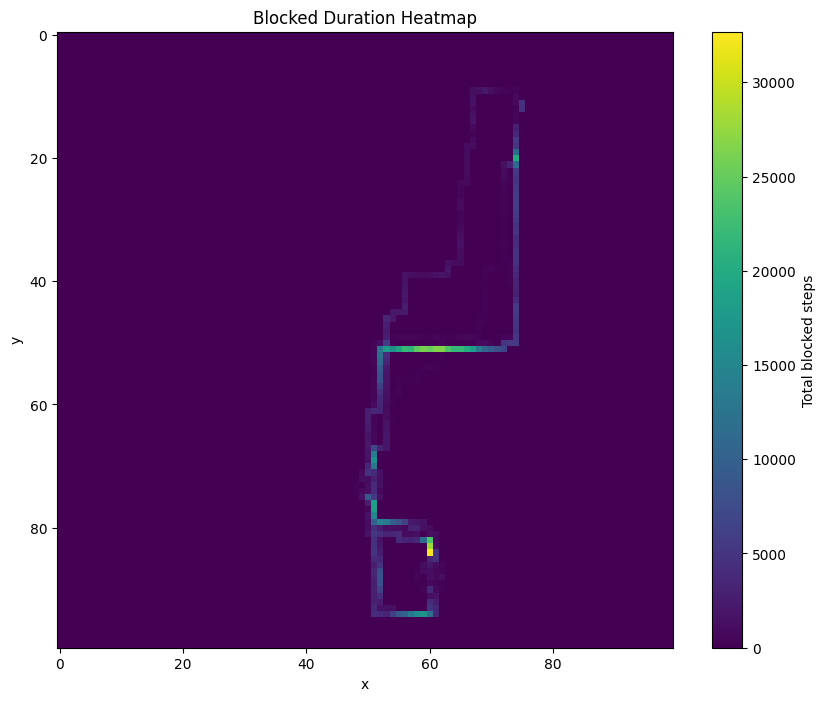

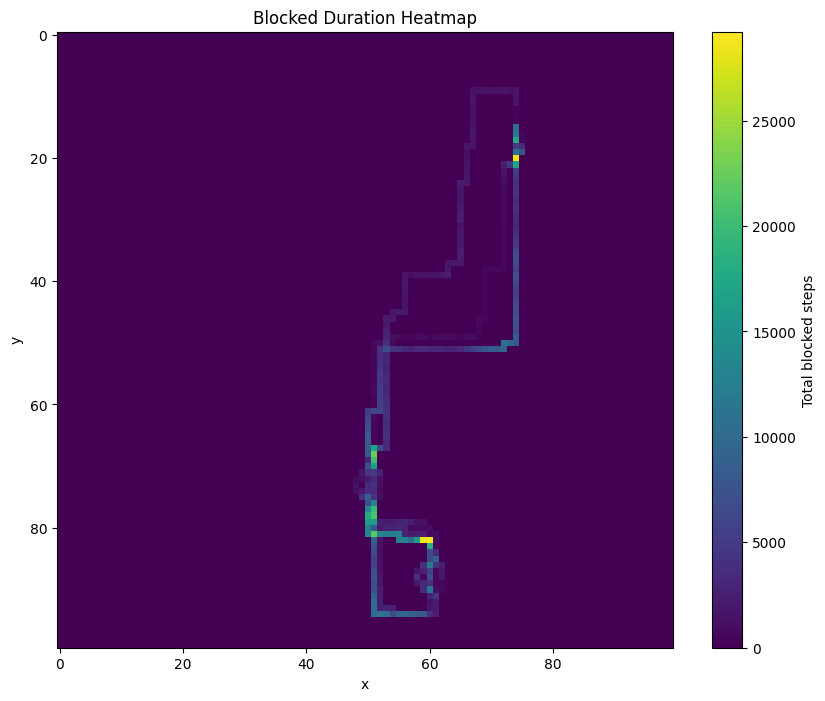

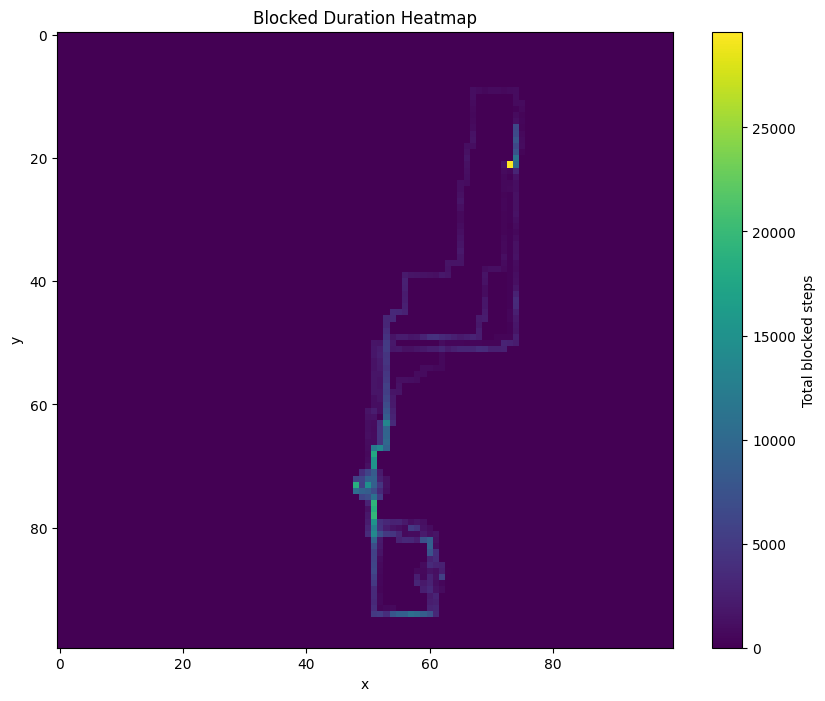

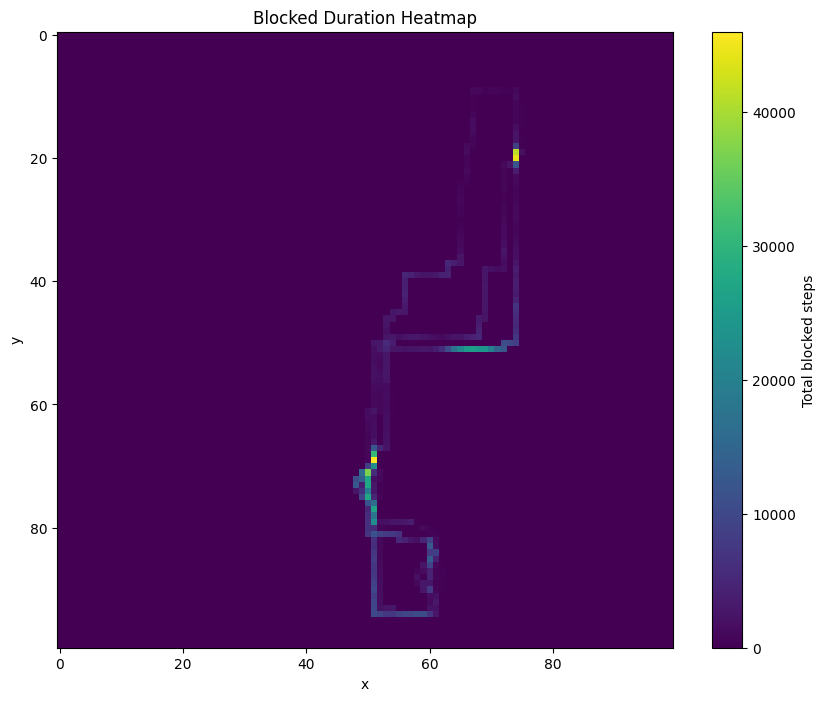

In [66]:
# Blockage duration heatmaps

duration_counts, duration_heatmap = plot_blocked_duration_heatmap(
    loc_exp1,
    height=GRID_HEIGHT,
    width=GRID_WIDTH
)

duration_counts, duration_heatmap = plot_blocked_duration_heatmap(
    loc_exp2,
    height=GRID_HEIGHT,
    width=GRID_WIDTH
)
duration_counts, duration_heatmap = plot_blocked_duration_heatmap(
    loc_exp3,
    height=GRID_HEIGHT,
    width=GRID_WIDTH
)
duration_counts, duration_heatmap = plot_blocked_duration_heatmap(
    loc_exp4,
    height=GRID_HEIGHT,
    width=GRID_WIDTH
)

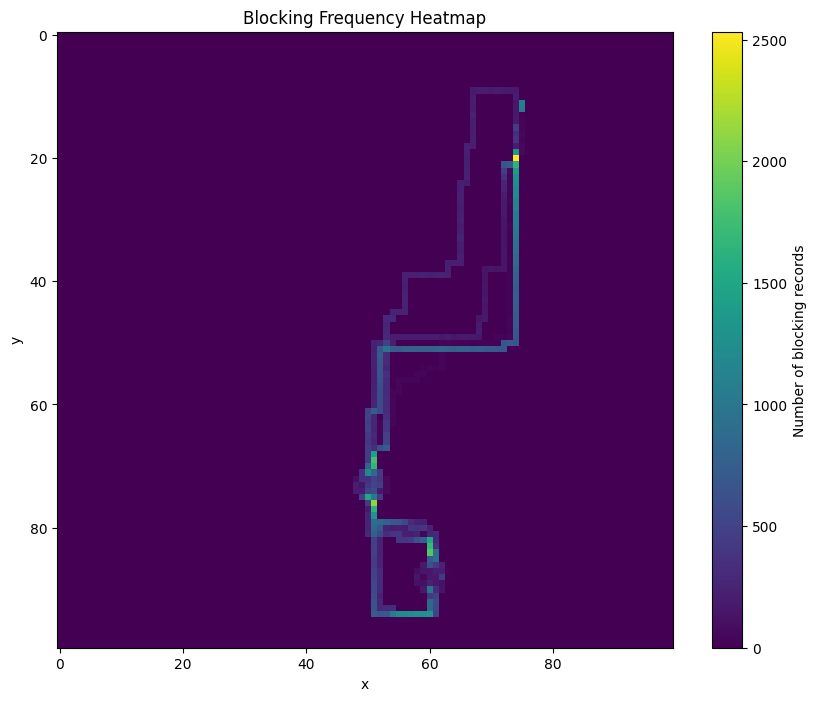

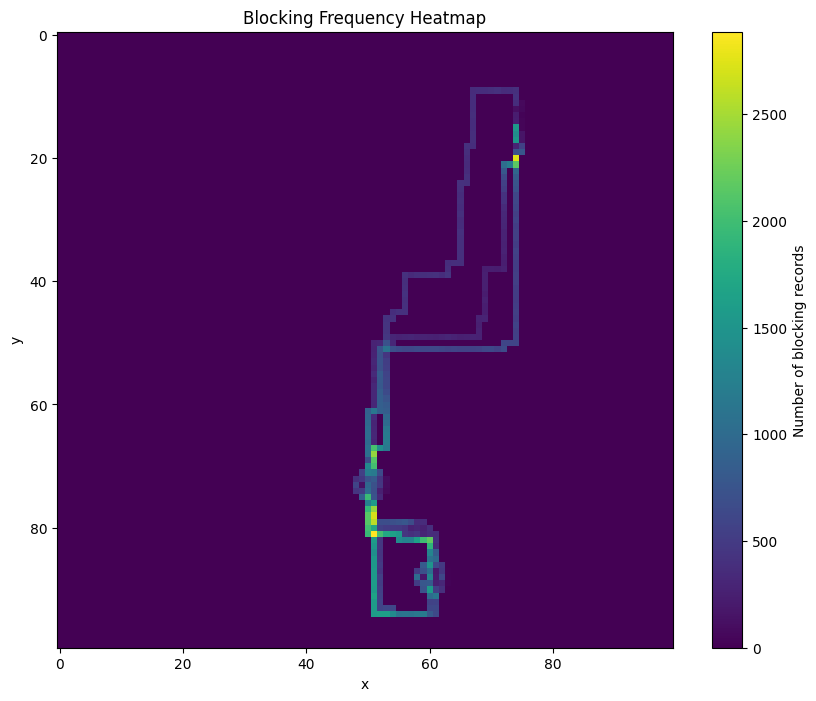

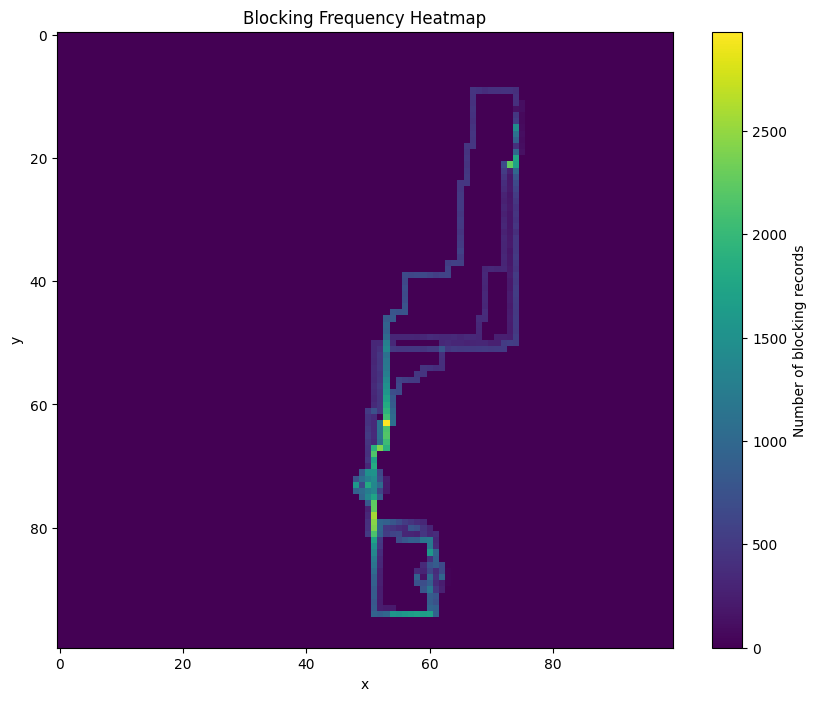

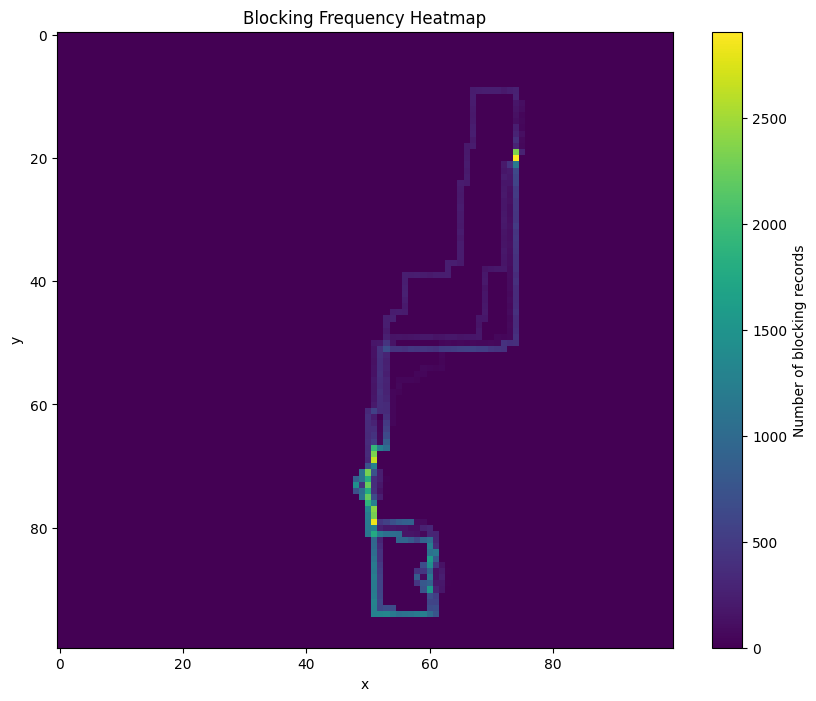

In [67]:
# frequency heatmap

frequency_counts, frequency_heatmap = plot_blocking_frequency_heatmap(
    loc_exp1,
    height=GRID_HEIGHT,
    width=GRID_WIDTH
)

frequency_counts, frequency_heatmap = plot_blocking_frequency_heatmap(
    loc_exp2,
    height=GRID_HEIGHT,
    width=GRID_WIDTH
)

frequency_counts, frequency_heatmap = plot_blocking_frequency_heatmap(
    loc_exp3,
    height=GRID_HEIGHT,
    width=GRID_WIDTH
)

frequency_counts, frequency_heatmap = plot_blocking_frequency_heatmap(
    loc_exp4,
    height=GRID_HEIGHT,
    width=GRID_WIDTH
)

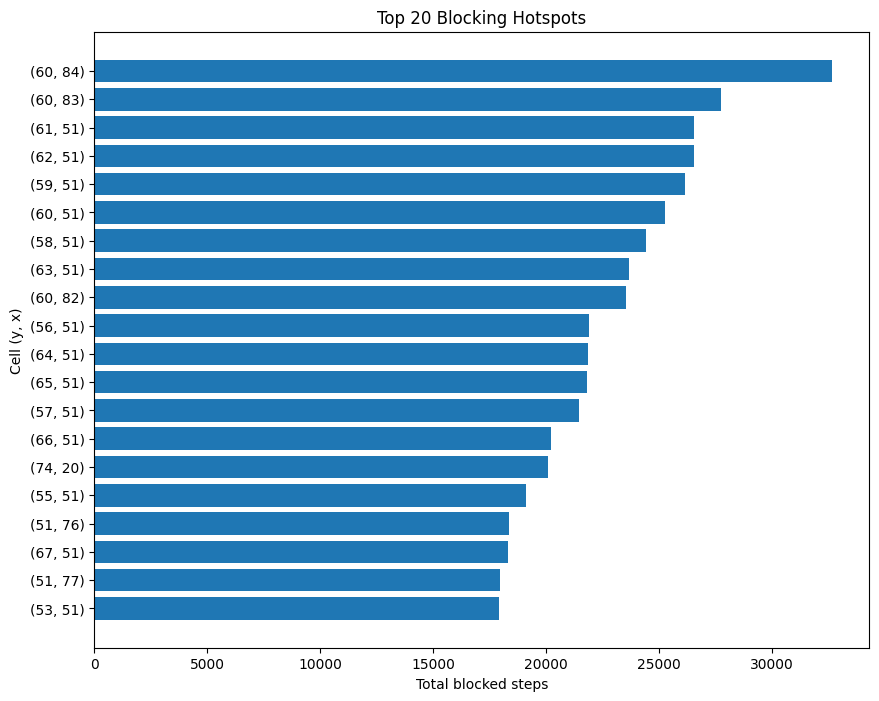

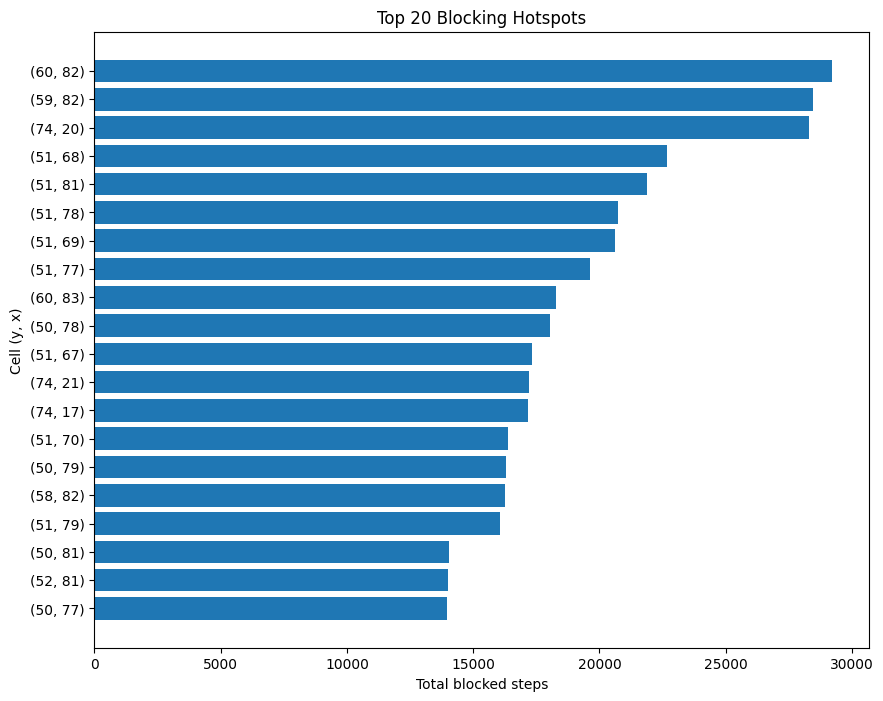

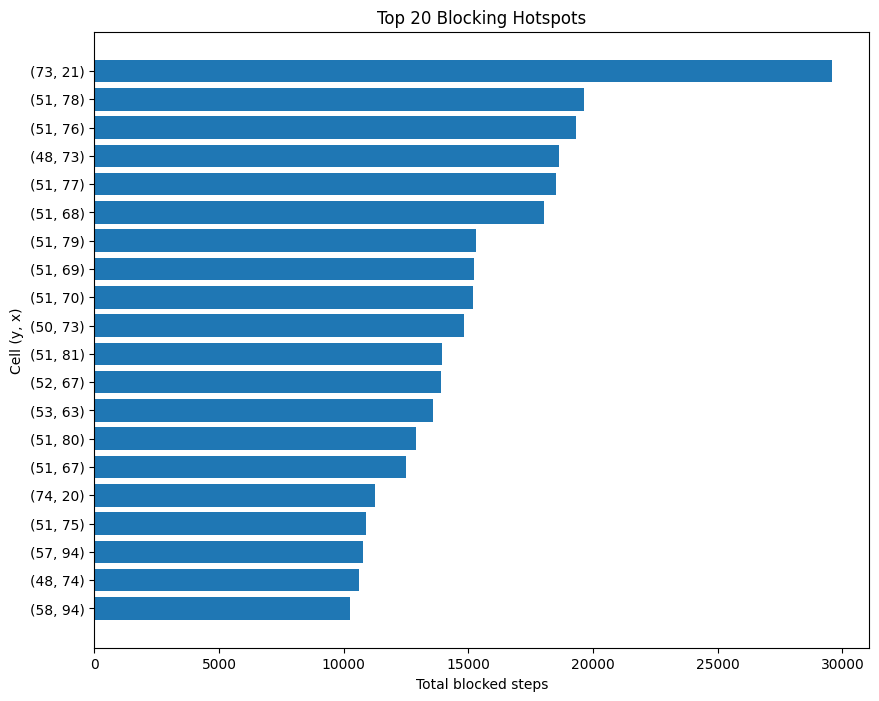

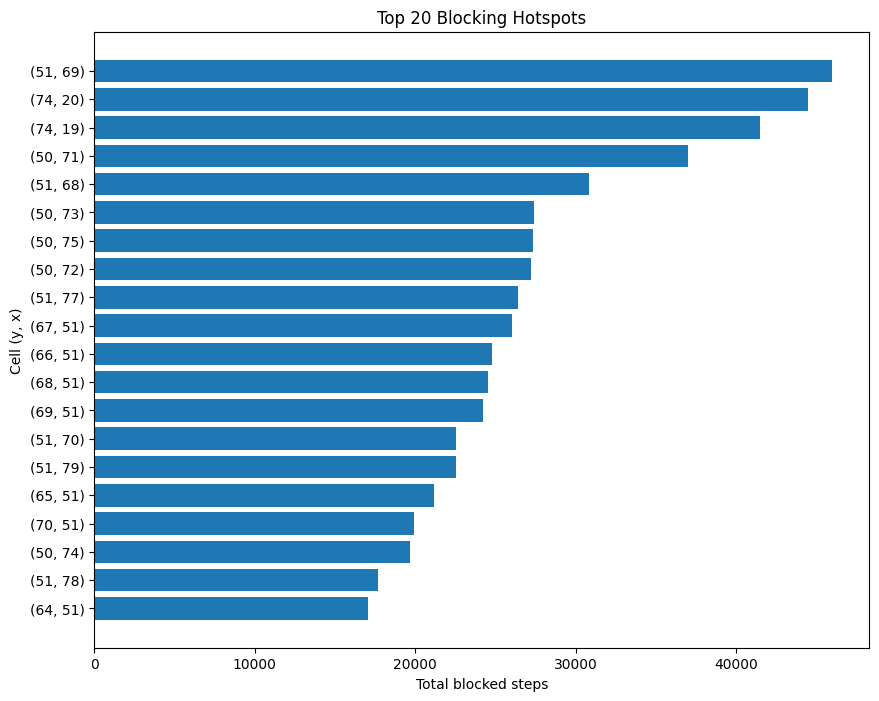

In [68]:
# top hot spots

hotspots = plot_top_blocking_hotspots(loc_exp1, n=20)
hotspots = plot_top_blocking_hotspots(loc_exp2, n=20)
hotspots = plot_top_blocking_hotspots(loc_exp3, n=20)
hotspots = plot_top_blocking_hotspots(loc_exp4, n=20)

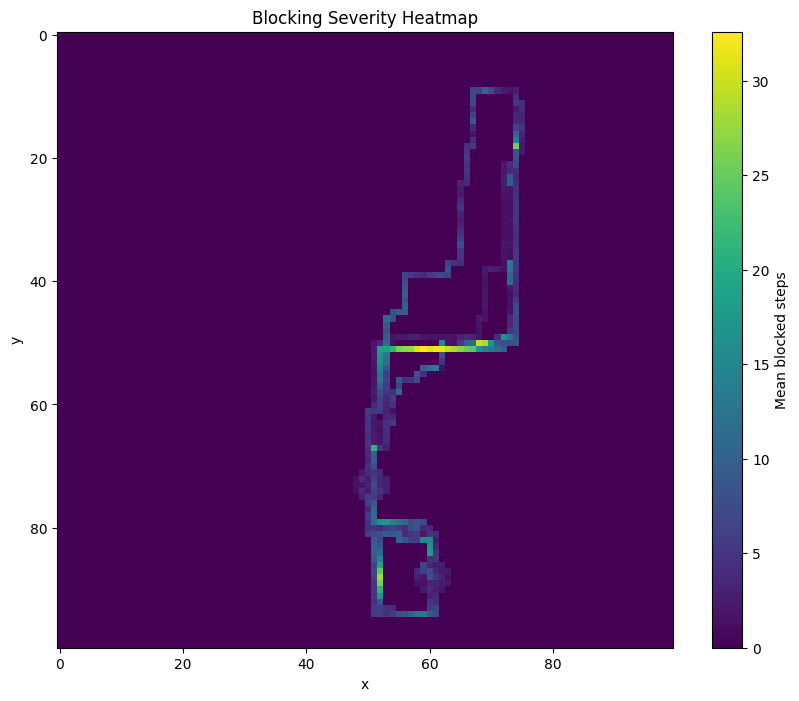

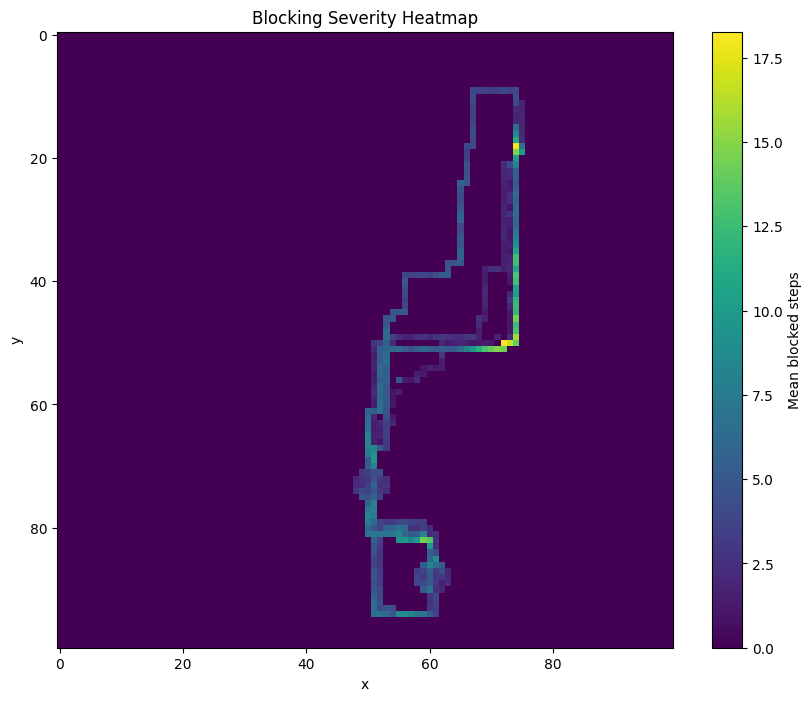

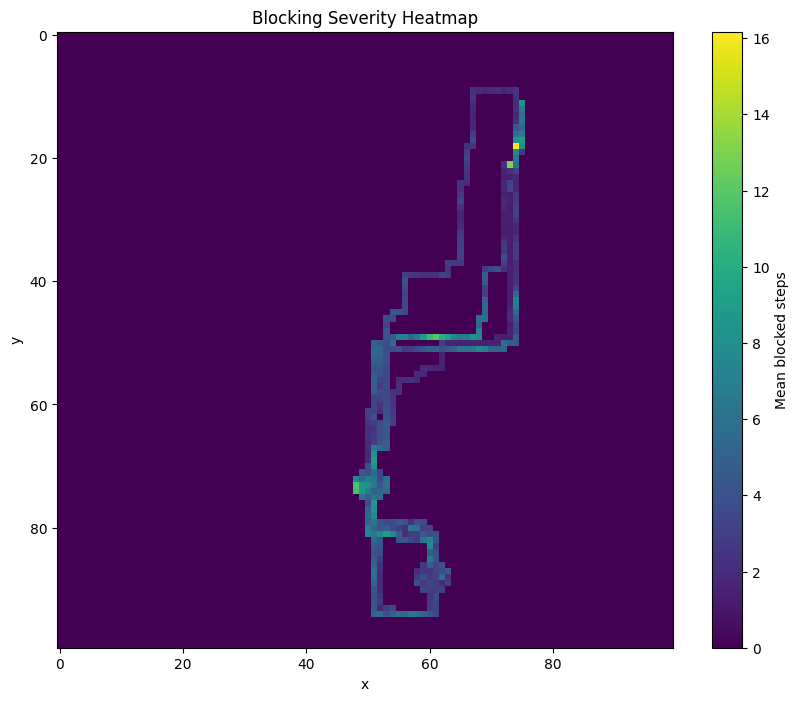

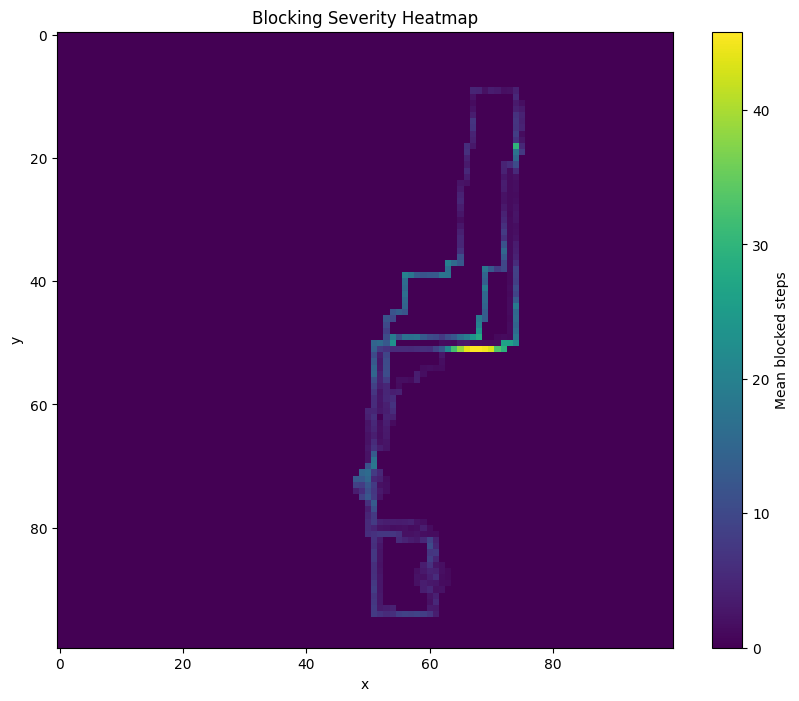

In [69]:
severity_counts, severity_heatmap = plot_severity_heatmap(
    loc_exp1,
    height=GRID_HEIGHT,
    width=GRID_WIDTH
)

severity_counts, severity_heatmap = plot_severity_heatmap(
    loc_exp2,
    height=GRID_HEIGHT,
    width=GRID_WIDTH
)

severity_counts, severity_heatmap = plot_severity_heatmap(
    loc_exp3,
    height=GRID_HEIGHT,
    width=GRID_WIDTH
)

severity_counts, severity_heatmap = plot_severity_heatmap(
    loc_exp4,
    height=GRID_HEIGHT,
    width=GRID_WIDTH
)

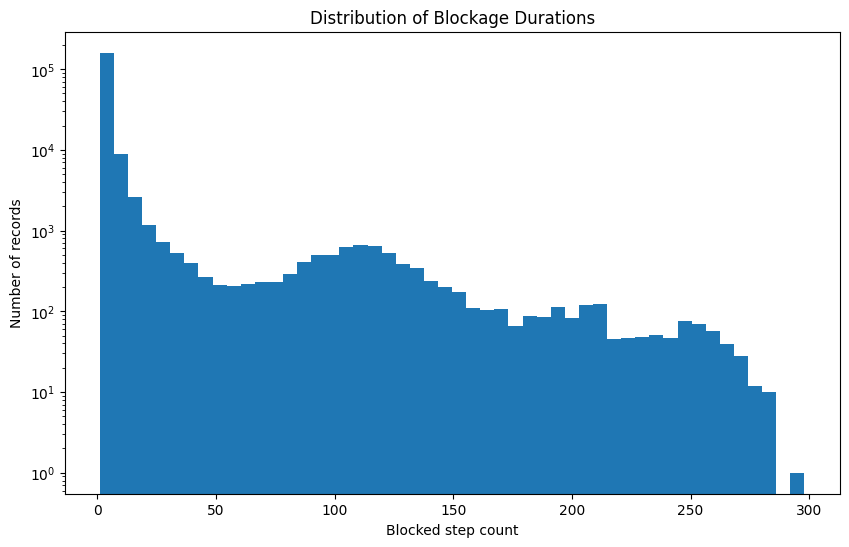

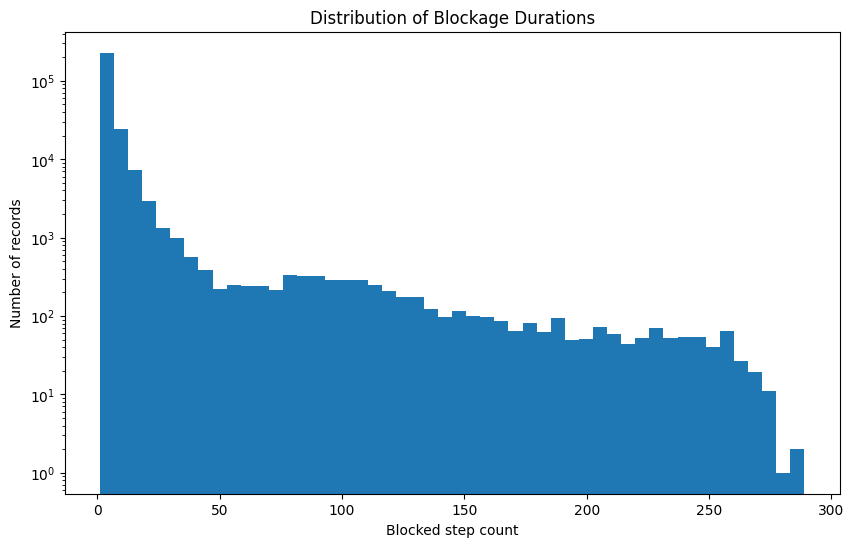

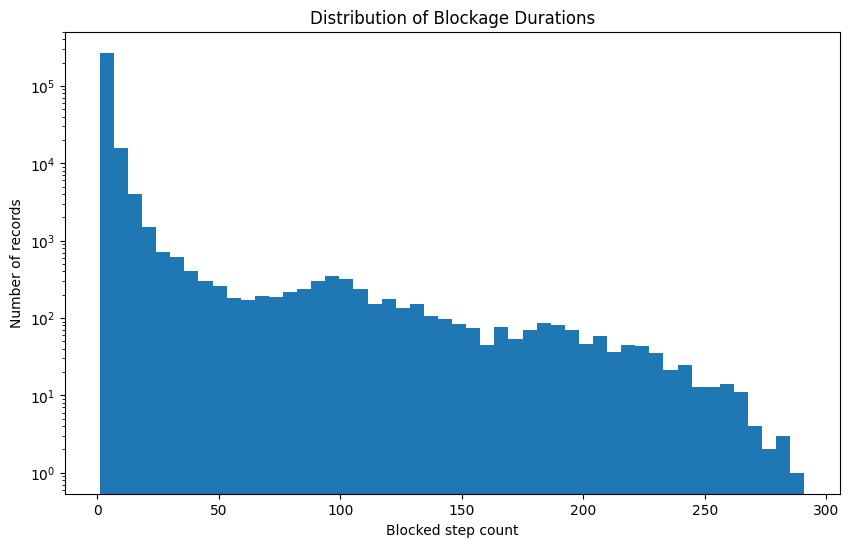

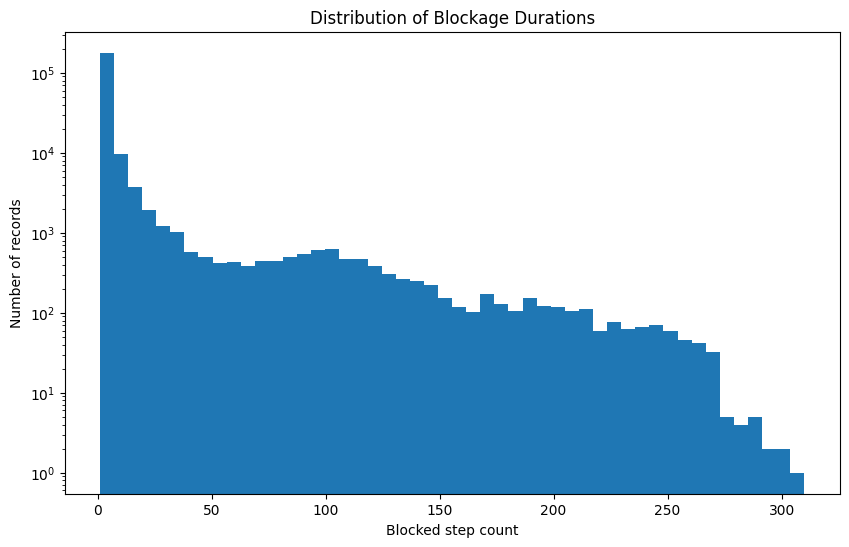

In [70]:
plot_blockage_duration_distribution(loc_exp1)
plot_blockage_duration_distribution(loc_exp2)
plot_blockage_duration_distribution(loc_exp3)
plot_blockage_duration_distribution(loc_exp4)

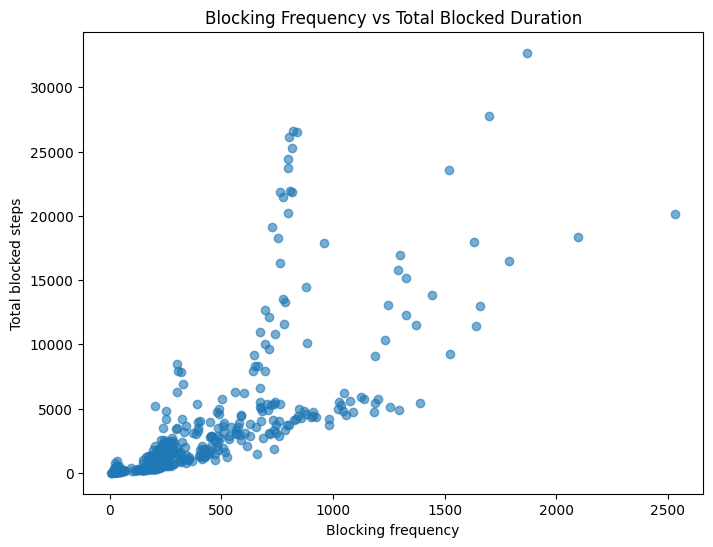

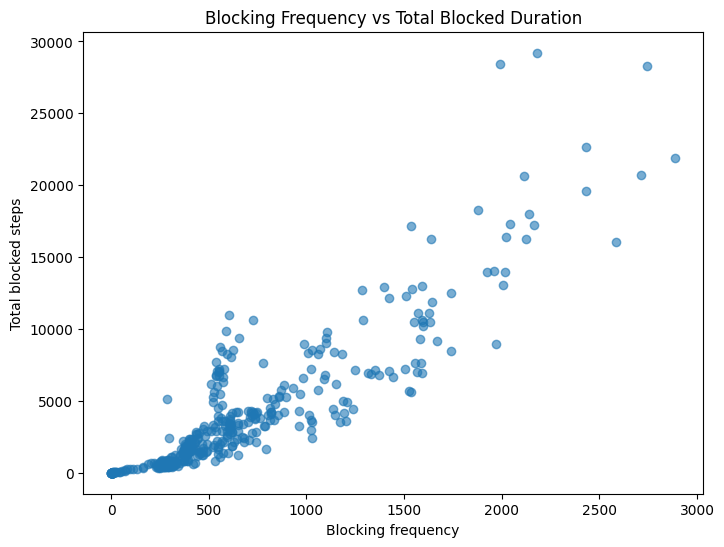

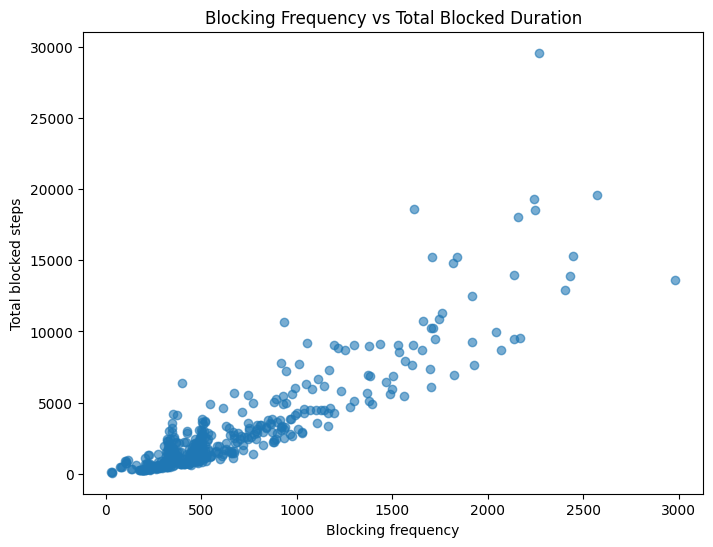

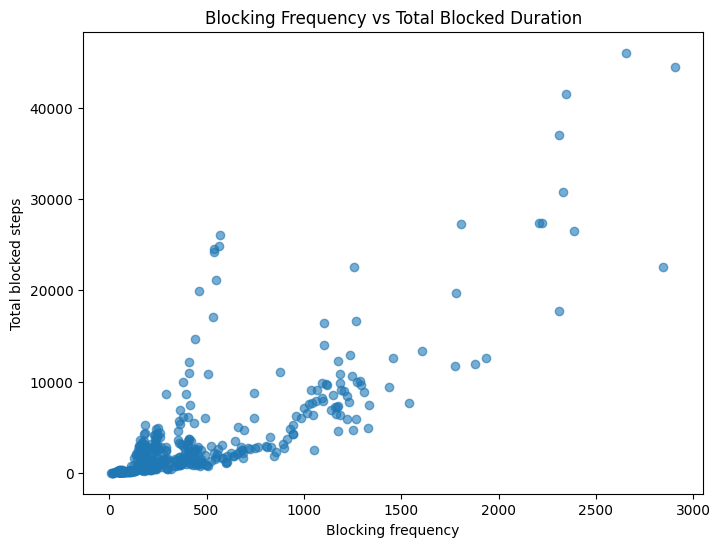

In [71]:
cell_stats = plot_frequency_vs_duration(loc_exp1)
cell_stats = plot_frequency_vs_duration(loc_exp2)
cell_stats = plot_frequency_vs_duration(loc_exp3)
cell_stats = plot_frequency_vs_duration(loc_exp4)

## Step 11: Traffic Light Behavior Analysis

After we have analyzed the conflict redistribution, it is now time to examine our traffic lights in detail and which behavior the rules we put are inducing.
For this we want to measure what the distribution of red light, green light, release and reserve events of our traffic lights are, the waiting times it induced, which was side was prioritized and whether the re distribution of conflicts was balanced.

In [72]:
# lets merge the two data frames for the traffic light experiments together

df_exp3["source"] = "Reward Shaping + TL"
df_exp4["source"] = "Vanilla + TL"
merged = pd.concat([df_exp3, df_exp4], ignore_index=True)

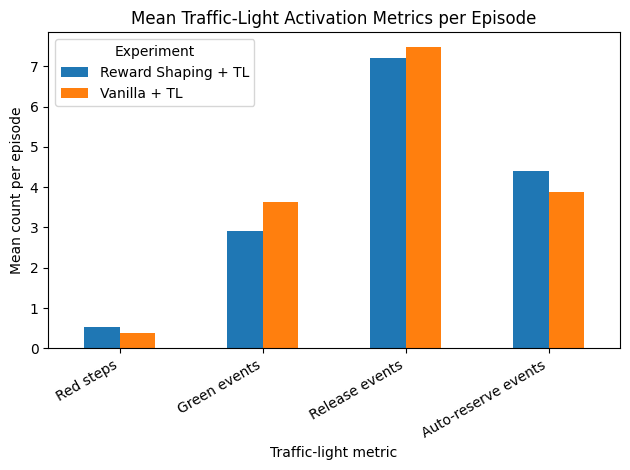

In [73]:
# lets measure distributions for traffic light metrics

activation_metrics = [
    "traffic_light_red_steps",
    "traffic_light_green_events",
    "traffic_light_release_events",
    "traffic_light_auto_reserve_events"
]

activation_summary = (
    merged
    .groupby("source")[activation_metrics]
    .mean()
    .T
)

ax = activation_summary.plot(kind="bar")

plt.title("Mean Traffic-Light Activation Metrics per Episode")
plt.xlabel("Traffic-light metric")
plt.ylabel("Mean count per episode")

ax.set_xticklabels([
    "Red steps",
    "Green events",
    "Release events",
    "Auto-reserve events"
], rotation=30, ha="right")

ax.legend(
    labels=["Reward Shaping + TL", "Vanilla + TL"],
    title="Experiment"
)

plt.xticks(rotation=30, ha="right")
plt.legend(title="Experiment")
plt.tight_layout()
plt.show()



                         mean  median       std  min    max
source                                                     
Reward Shaping + TL  0.467800     0.0  4.201130  0.0  140.0
Vanilla + TL         0.303267     0.0  2.777102  0.0  128.0


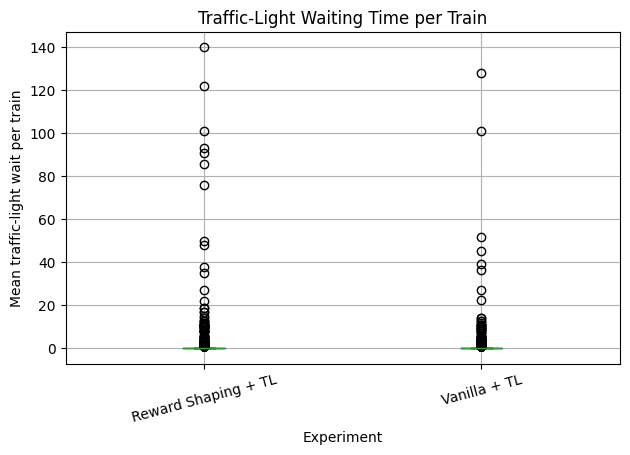

In [74]:
# now we have the distribution of the waiting time

wait_metric = "mean_traffic_light_wait_per_agent"

wait_summary = (
    merged
    .groupby("source")[wait_metric]
    .agg(["mean", "median", "std", "min", "max"])
)

print(wait_summary)

merged.boxplot(
    column=wait_metric,
    by="source",
    grid=True
)

plt.title("Traffic-Light Waiting Time per Train")
plt.suptitle("")
plt.xlabel("Experiment")
plt.ylabel("Mean traffic-light wait per train")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [75]:
print(wait_summary.columns)

Index(['mean', 'median', 'std', 'min', 'max'], dtype='str')


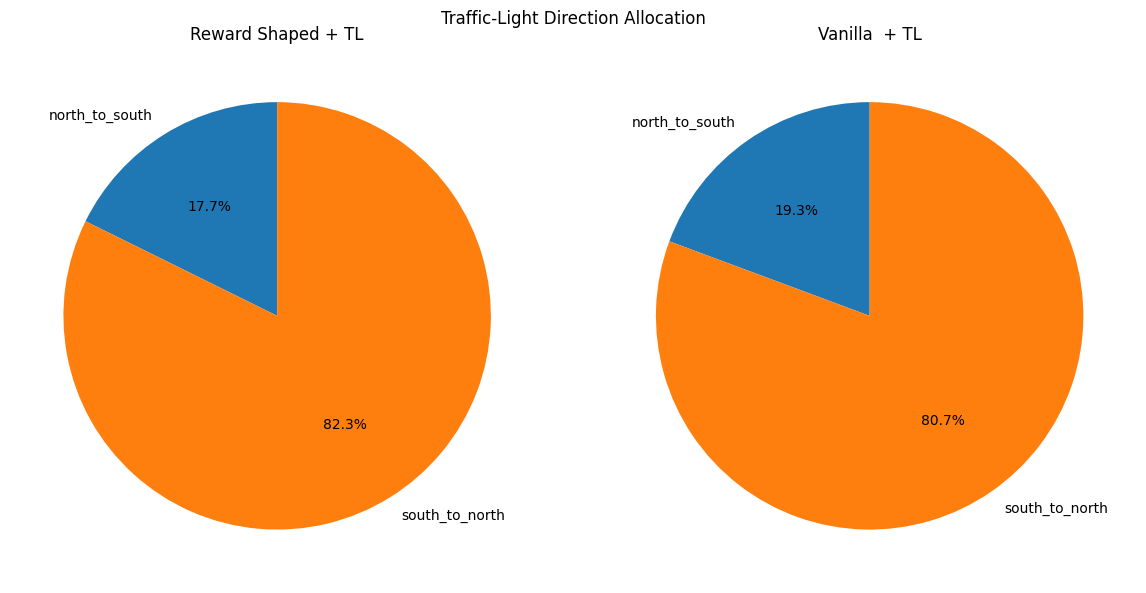

In [76]:
# now we are analyzing the directional bias

# first get the traffic light specific metrics

directions3 = pd.read_csv("metrics_exp3/traffic_light_directions_exp3.csv")
directions4 = pd.read_csv("metrics_exp4/traffic_light_directions_exp4.csv")

exp3_share = (
    directions3
    .groupby("direction")["green_or_reserve_count"]
    .sum()
)

exp4_share = (
    directions4
    .groupby("direction")["green_or_reserve_count"]
    .sum()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))


axes[0].pie(
    exp3_share.values,
    labels=exp3_share.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[0].set_title("Reward Shaped + TL")


axes[1].pie(
    exp4_share.values,
    labels=exp4_share.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[1].set_title("Vanilla  + TL")

plt.suptitle("Traffic-Light Direction Allocation")
plt.tight_layout()
plt.show()

1197
1010


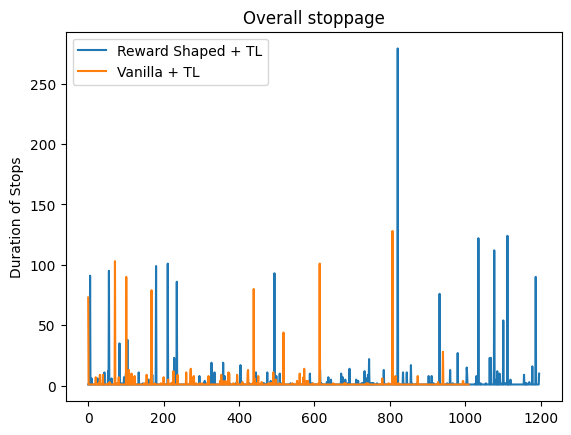

In [77]:
# lets try the same with the stop step count

entry3 = pd.read_csv("metrics_exp3/traffic_light_entries_exp3.csv")
entry4 = pd.read_csv("metrics_exp4/traffic_light_entries_exp4.csv")

col3 = entry3["red_step_count"]
col4 = entry4["red_step_count"]

print(len(col3))
print(len(col4))

plt.plot(col3, label="Reward Shaped + TL")
plt.plot(col4, label="Vanilla + TL")


plt.ylabel("Duration of Stops")
plt.title("Overall stoppage")
plt.legend()
plt.show()